Estimation of COVID-19 Pandemic
Loading Data
We will use data on COVID-19 infected individuals, provided by the Center for Systems Science and Engineering (CSSE) at Johns Hopkins University. Dataset is available in this GitHub Repository.

We can load the most recent data directly from GitHub using pd.read_csv. If for some reason the data is not available, you can always use the copy available locally in the data folder - just uncomment the line below that defines base_url:

In [22]:
base_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/" # loading from Internet
# base_url = "../../data/COVID/" # loading from disk
infected_dataset_url = base_url + "time_series_covid19_confirmed_global.csv"
recovered_dataset_url = base_url + "time_series_covid19_recovered_global.csv"
deaths_dataset_url = base_url + "time_series_covid19_deaths_global.csv"
countries_dataset_url = base_url + "../UID_ISO_FIPS_LookUp_Table.csv"

Let's now load the data for infected individuals and see how the data looks like:

In [23]:
import pandas as pd
infected = pd.read_csv(infected_dataset_url)
infected.head()
# province 州
# state 州
# latitude 緯度
# longitude 経度

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


We can see that each row of the table defines the number of infected individuals for each country and/or province, and columns correspond to dates. Similar tables can be loaded for other data, such as number of recovered and number of deaths.
table格子状のデータ表
columns列
correspond to対応する
datas日付

In [24]:
#pandasを使うときは、あらかじめ変数を作らなくても、pd.read_csvで勝手に変数を作ってくれる。
# pd .read_csv(deaths_dataset_url)の書き方はURLを読み込んでいない何もないとき、つまり一番初めにする書き方
recovered = pd.read_csv(recovered_dataset_url)
deaths = pd.read_csv(deaths_dataset_url)

Making Sense of the Data
From the table above the role of province column is not clear. Let's see the different values that are present in Province/State column:
make sense of the data理にかなってるデータ
above上

In [25]:
#解像度ランキング、丁寧な国ランキング
infected['Country/Region'].value_counts()

Country/Region
China                   34
Canada                  16
United Kingdom          15
France                  12
Australia                8
                        ..
West Bank and Gaza       1
Winter Olympics 2022     1
Yemen                    1
Zambia                   1
Zimbabwe                 1
Name: count, Length: 201, dtype: int64

In [26]:
#.value_counts()
#データの中で、どの値が何回出てくるかを数えるpandasのメソッド。
infected['Province/State'].value_counts()

#国によって「報告のスタイル」が違う、解像度がバラバラ
#NaNは国の統計、雑な国
#NoNでない国は州ごとに報告している国、丁寧な国

Province/State
Australian Capital Territory                    1
New South Wales                                 1
Northern Territory                              1
Queensland                                      1
South Australia                                 1
                                               ..
Jersey                                          1
Montserrat                                      1
Pitcairn Islands                                1
Saint Helena, Ascension and Tristan da Cunha    1
Turks and Caicos Islands                        1
Name: count, Length: 91, dtype: int64

From the names we can deduce that countries like Australia and China have more detailed breakdown by provinces. Let's look for information on China to see the example:
deduce結論づける
breakdown細かい分析
look for探す

In [27]:
#infectedから列'Country/Regionを[]で抜き出して、'China'と等しい列を抜き出す
#pandasは列を指定すれば勝手に行を抜き出してくれる。
#pandasで表を作ったらその表を詳細的に見たいときは[]で絞り込めばいい
infected[infected['Country/Region']=='China']

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
59,Anhui,China,31.8257,117.2264,1,9,15,39,60,70,...,2275,2275,2275,2275,2275,2275,2275,2275,2275,2275
60,Beijing,China,40.1824,116.4142,14,22,36,41,68,80,...,40774,40774,40774,40774,40774,40774,40774,40774,40774,40774
61,Chongqing,China,30.0572,107.8740,6,9,27,57,75,110,...,14715,14715,14715,14715,14715,14715,14715,14715,14715,14715
62,Fujian,China,26.0789,117.9874,1,5,10,18,35,59,...,17122,17122,17122,17122,17122,17122,17122,17122,17122,17122
63,Gansu,China,35.7518,104.2861,0,2,2,4,7,14,...,1742,1742,1742,1742,1742,1742,1742,1742,1742,1742
64,Guangdong,China,23.3417,113.4244,26,32,53,78,111,151,...,103248,103248,103248,103248,103248,103248,103248,103248,103248,103248
65,Guangxi,China,23.8298,108.7881,2,5,23,23,36,46,...,13371,13371,13371,13371,13371,13371,13371,13371,13371,13371
66,Guizhou,China,26.8154,106.8748,1,3,3,4,5,7,...,2534,2534,2534,2534,2534,2534,2534,2534,2534,2534
67,Hainan,China,19.1959,109.7453,4,5,8,19,22,33,...,10483,10483,10483,10483,10483,10483,10483,10483,10483,10483
68,Hebei,China,39.5490,116.1306,1,1,2,8,13,18,...,3292,3292,3292,3292,3292,3292,3292,3292,3292,3292


Pre-processing the Data
We are not interested in breaking countries down to further territories, thus we would first get rid of this breakdown and add information on all territories together, to get info for the whole country. This can be done using groupby:
pre-processing前処理
furtherさらに
territories領域
break A downAを細かくする

In [28]:
#.groupby()
#   groupbyは、指定した列の値ごとに行をグループ化するpandasのメソッド。
#   china,italy,japanなどの国ごとにグループ
#.sum()
#   sumは、数値の列を合計するpandasのメソッド。
#groupby()とsum()をコンビで使っているからグループごとの合計を出している。

infected = infected.groupby('Country/Region').sum()
recovered = recovered.groupby('Country/Region').sum()
deaths = deaths.groupby('Country/Region').sum()

#= があると、Jupyterは「画面に表示するのをお休み」だからinfected.head()が必要
infected.head()


,Province/State,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,,33.93911,67.709953,0,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
Albania,,41.15330,20.168300,0,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
Algeria,,28.03390,1.659600,0,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
Andorra,,42.50630,1.521800,0,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
Angola,,-11.20270,17.873900,0,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


You can see that due to using groupby all DataFrames are now indexed by Country/Region. We can thus access the data for a specific country by using .loc:
due toおかげで
index見出しをつける

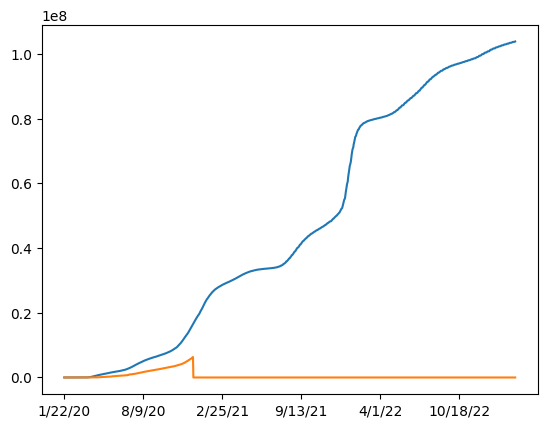

In [29]:
# matplotlibのpylotを使ってグラフ化
#loc[]は、行を指定するpandasのメソッド。
#read_csvしたのでPandasが勝手に気を利かせて名札をセットしてくれる。グラフのx,y軸のラベルなどの定義不要
import matplotlib.pyplot as plt
#usの列を抽出して、一本のビラにして、3列目以降を抜き取ってグラフ化
infected.loc['US'][3:].plot()
recovered.loc['US'][3:].plot()
plt.show()


Note how we use [3:] to remove the first three elements of a sequence that contain non-date metadata (the Province/State and geolocation columns). We can also drop those three columns altogether:

In [30]:
#.drop()
#   dropは、指定した列を削除するpandasのメソッド。
#columns=['Lat','Long','Province/State']
#   Lat,Long,Province/Stateの列を削除する
#inplace=True
#   容赦なく上書き保存していいという意味
infected.drop(columns=['Lat','Long','Province/State'],inplace=True)
recovered.drop(columns=['Lat','Long','Province/State'],inplace=True)
deaths.drop(columns=['Lat','Long','Province/State'],inplace=True)

Investigating the Data
Let's now switch to investigating a specific country. Let's create a frame that contains the data on infections indexed by date:

In [31]:

#.DataFrame()
#exelの表のようなものを作るpandasのメソッド。
#df = pd.DataFrame({
#    '列の名前1' : 中に入れたいデータ1,
#    '列の名前2' : 中に入れたいデータ2,
#    '列の名前3' : 中に入れたいデータ3
#})
df = pd.DataFrame({ 'infected' : infected.loc['US'],
                    'recovered' : recovered.loc['US'],
                    'deaths' : deaths.loc['US']})
#.to_datetime
#   to_datetimeは、文字列を日付に変換するpandasのメソッド。
#df.indexはメソッドではなく、dfの行の左端の縦の名札データを指す。プロパティという。
#主語がないときは、親玉のpdを呼び出さないといけない。
#.は~の中の　と訳す
df.index = pd.to_datetime(df.index)
df



C:\Users\yukio\AppData\Local\Temp\ipykernel_32868\1074289172.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


,infected,recovered,deaths
2020-01-22,1,0,0
2020-01-23,1,0,0
2020-01-24,2,0,0
2020-01-25,2,0,0
2020-01-26,5,0,0
...,...,...,...
2023-03-05,103646975,0,1122134
2023-03-06,103655539,0,1122181
2023-03-07,103690910,0,1122516
2023-03-08,103755771,0,1123246


<Axes: >

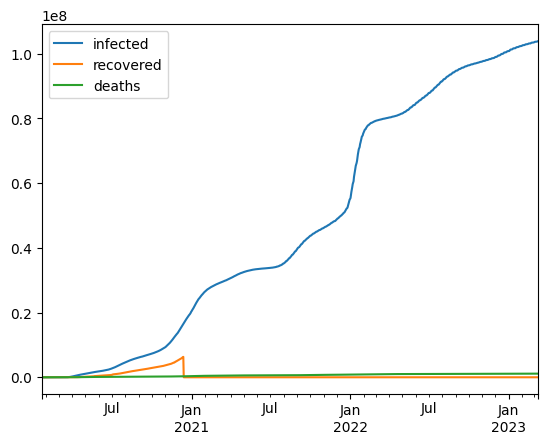

In [32]:
#plot
#   PandasとMatplotlibのハイブリッド、表も作るしグラフも作るpandasのメソッド。
df.plot()

Now let's compute the number of new infected people each day. This will allow us to see the speed at which pandemic progresses. The easiest day to do it is to use diff:
dayやり方
pandemic世界的大流行

<Axes: >

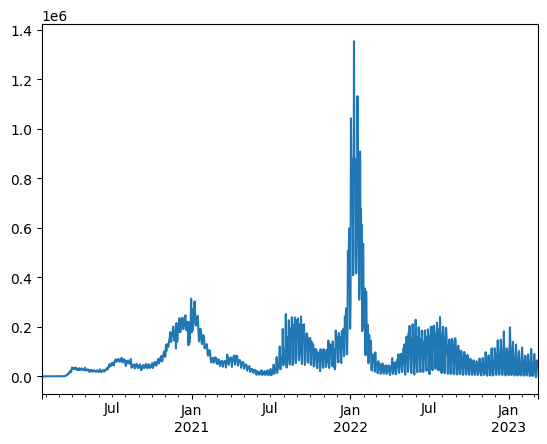

In [ ]:
#diff()
#   diffは、diffrentの略で、前の行との差を出すpandasのメソッド。

df['ninfected'] = df['infected'].diff()
df['ninfected'].plot()

We can see high fluctuations in data. Let's look closer at one of the months:
fluctuation変動
look closerもっと近くで見る


<Axes: >

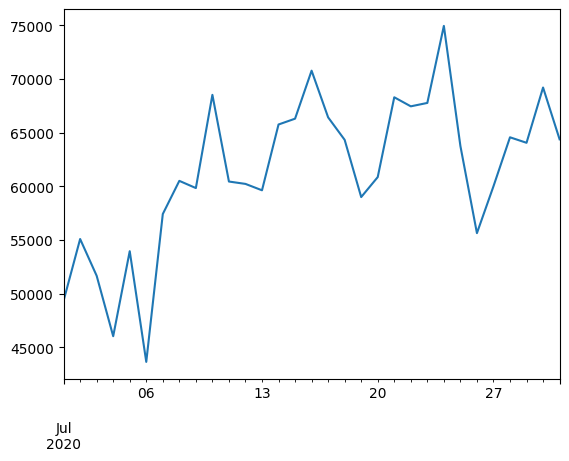

In [34]:
#&は'かつ'
#==などの条件式があるとき、条件式を満たす行指定に切り替わる
df['ninfected'][(df.index.year==2020) & (df.index.month==7)].plot()

It clearly looks like there are weekly fluctuations in data. Because we want to be able to see the trends, it makes sense to smooth out the curve by computing running average (i.e. for each day we will compute the average value of the previous several days):
smooth outなめらかにする

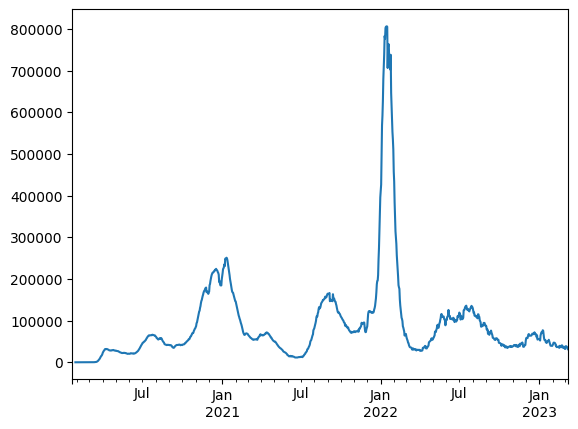

In [35]:
#df['ninfected']
#   １日の新規感染者数
#.rolling(window=7)
#   for文（ループ処理）と同じように、上から下まで1行ずつ「7日間、次の7日間、その次の7日間…」と連続で取り出す動きをするpandasのメソッド。
#一グループずつmeanに渡す、ほぼfor文、for文の中で「7日間のデータをmeanに渡す」という動きをする。
#mean()
#   rollingで囲んだデータの平均を出すpandasのメソッド。
#、毎日毎日、1日ずつじわじわ進みながら、その日その日の「過去7日間の平均」の点を打っている
df['ninfav'] = df['ninfected'].rolling(window=7).mean()
df['ninfav'].plot()
plt.show()

In order to be able to compare several countries, we might want to take the country's population into account, and compare the percentage of infected individuals with respect to country's population. In order to get country's population, let's load the dataset of countries:
population人口
with respect to X　Xに対して
might　＃＃分をマイルドにする
take A into accountAを考慮する

In [36]:
countries = pd.read_csv(countries_dataset_url)
countries

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Population
0,4,AF,AFG,4.0,NaN,NaN,NaN,Afghanistan,33.939110,67.709953,Afghanistan,38928341.0
1,8,AL,ALB,8.0,NaN,NaN,NaN,Albania,41.153300,20.168300,Albania,2877800.0
2,10,AQ,ATA,10.0,NaN,NaN,NaN,Antarctica,-71.949900,23.347000,Antarctica,NaN
3,12,DZ,DZA,12.0,NaN,NaN,NaN,Algeria,28.033900,1.659600,Algeria,43851043.0
4,20,AD,AND,20.0,NaN,NaN,NaN,Andorra,42.506300,1.521800,Andorra,77265.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4316,84056037,US,USA,840.0,56037.0,Sweetwater,Wyoming,US,41.659439,-108.882788,"Sweetwater, Wyoming, US",42343.0
4317,84056039,US,USA,840.0,56039.0,Teton,Wyoming,US,43.935225,-110.589080,"Teton, Wyoming, US",23464.0
4318,84056041,US,USA,840.0,56041.0,Uinta,Wyoming,US,41.287818,-110.547578,"Uinta, Wyoming, US",20226.0
4319,84056043,US,USA,840.0,56043.0,Washakie,Wyoming,US,43.904516,-107.680187,"Washakie, Wyoming, US",7805.0


Because this dataset contains information on both countries and provinces, to get the population of the whole country we need to be a little bit clever:
because A ,B AだからB


In [37]:
#.isna()　＊is NaN
#空っぽの場所を取り出し
countries[(countries['Country_Region']=='US') & countries['Province_State'].isna()]
#アメリカ合衆国がみつかる

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Population
915,840,US,USA,840.0,NaN,NaN,NaN,US,40.0,-100.0,US,329466283.0


<Axes: >

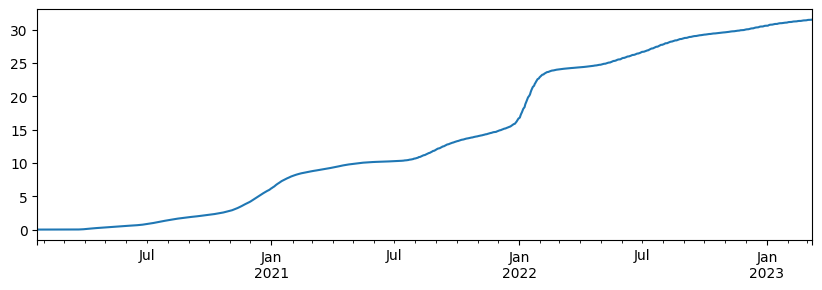

In [38]:
pop = countries[(countries['Country_Region']=='US') & countries['Province_State'].isna()]['Population'].iloc[0]
# いまの状態（ミニ表）
# 915    329466283.0  名札番号は永久不滅
#df['infected']は、アメリカ合衆国の感染者数の列
df['pinfected'] = df['infected']*100 / pop
df['pinfected'].plot( figsize=(10,3))


Computing  Rt 
To see how infectious is the disease, we look at the basic reproduction number  R0 , which indicated the number of people that an infected person would further infect. When  R0  is more than 1, the epidemic is likely to spread.

R0  is a property of the disease itself, and does not take into account some protective measures that people may take to slow down the pandemic. During the pandemic progression, we can estimate the reproduction number  Rt  at any given time  t . It has been shown that this number can be roughly estimated by taking a window of 8 days, and computing
epidemic急激な流行
property特性
infectious感染性
look at注目する
,whichそしてそれは…
infect感染させる
measures対策


where  It  is the number of newly infected individuals on day  t .

Let's compute  Rt  for our pandemic data. To do this, we will take a rolling window of 8 ninfected values, and apply the function to compute the ratio above:
ratio above上記の比率
apply AtoB AをBに適用する

<Axes: >

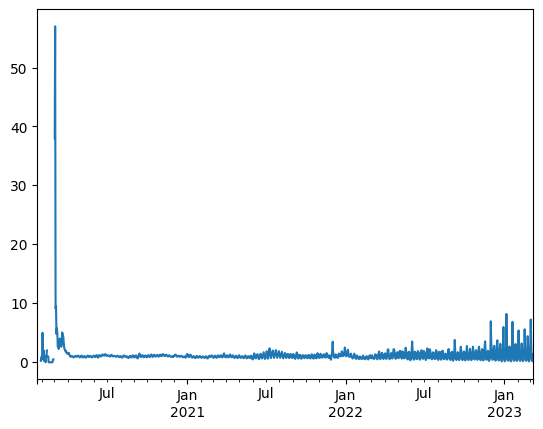

In [39]:
#lambda
#ｆ（ｘ）で関数を定義することができる。
#.apply
#関数に数値を渡して変数に入れるpandasのメソッド。
#rolling()で囲んだデータを、apply()で定義した関数に渡す動きをする。forに似ている。.
df['Rt'] = df['ninfected'].rolling(8).apply(lambda x: x[4:].sum()/x[:4].sum())
df['Rt'].plot()


You can see that there are some gaps in the graph. Those can be caused by either NaN, if inf values being present in the dataset. inf may be caused by division by 0, and NaN can indicate missing data, or no data available to compute the result (like in the very beginning of our frame, where rolling window of width 8 is not yet available). To make the graph nicer, we need to fill those values using replace and ffill function.

Let's further look at the beginning of the pandemic. We will also limit the y-axis values to show only values below 6, in order to see better, and draw horizontal line at 1.
gaps空白
division割り算

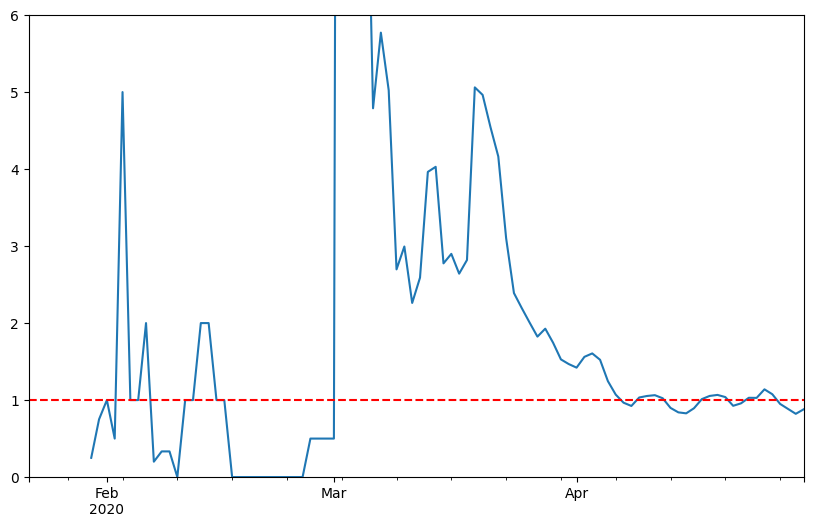

In [56]:
import numpy as np

#df[df.index < "2020-05-01"]
#dfの行の中で、行の名札が2020-05-01より前の行を抜き取る。
#infは無限という意味、無限はnumpyでしか表せないから、numpyのinfをnanに置き換える。nanは空っぽの意味。
#データ.replace(置き換えたいもの, 置き換えるもの)
#ffill()
# 空っぽのところを前の行の値で埋めるpandasのメソッド。
ax = df['Rt'][df.index < "2020-05-01"].replace(np.inf, np.nan).ffill().plot(figsize=(10, 6))
#ylim
#   y-axis limit
#0から6の間』だけに制限するmatplotlibのメソッド。
ax.set_ylim([0, 6])
#axhline
#   horizontal line 軸の水平線を引くmatplotlibのメソッド。
ax.axhline(1, linestyle='--', color='red')

Another interesting indicator of the pandemic is the derivative, or daily difference in new cases. It allows us to see clearly when pandemic is increasing or declining.
名詞A, or 名詞B Aという専門用語は、一般的な言葉で言うとBのこと
derivative微分
Another別の
indicator指標

<Axes: >

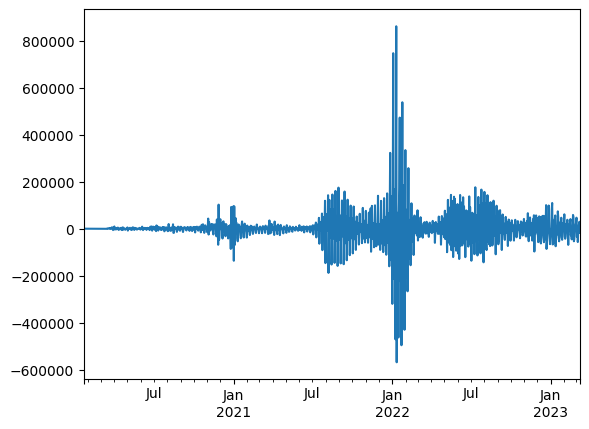

In [58]:
#現実の1日刻みのデータにおいて「極限まで細かく変化の勢い（傾き）を調べる」ということは、必然的に「前日との引き算（.diff()）をする」ということと完全に同じ意味になる
#infected（累計感染者数）→ninfected（新規感染者数）→ninfected.diff()（新規感染者数の変化の勢い）
#二回目微分
#2回微分が使われるのは、次のような一歩進んだ自動化やモデル作成をしたいとき,人間は一目で理解できる。
#土日に休みなので、グラフが線対称になっているのがわかる。
df['ninfected'].diff().plot()

Given the fact that there are a lot of fluctuations in data caused by reporting, it makes sense to smooth the curve by running rolling average to get the overall picture. Let's again focus on the first months of the pandemic:
fluctuations変動

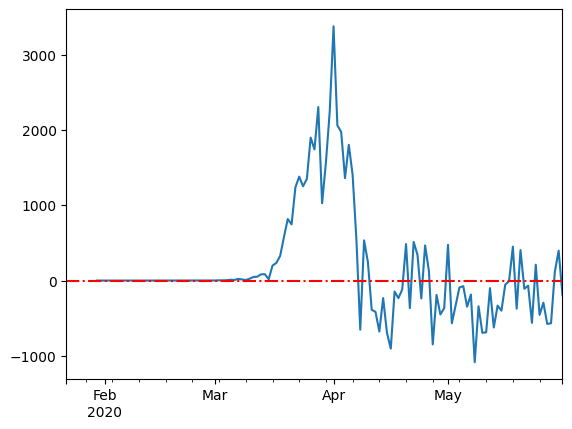

In [59]:
ax=df[df.index<"2020-06-01"]['ninfected'].diff().rolling(7).mean().plot()
ax.axhline(0,linestyle='-.',color='red')